# Linear Regression : Prostate Cancer

### Reproducing Hastie, Tibshirani and Friedman (2009), section 3.2.1

The data for this example come from a study by Stamey et al. (1989). They
examined the correlation between the level of prostate-specific antigen and
a number of clinical measures in men who were about to receive a radical
prostatectomy. The variables are log cancer volume (lcavol), log prostate
weight (lweight), age, log of the amount of benign prostatic hyperplasia
(lbph), seminal vesicle invasion (svi), log of capsular penetration (lcp),
Gleason score (gleason), and percent of Gleason scores 4 or 5 (pgg45).

We first load the data and examine it. 

In [40]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import statsmodels.api as sm
import scipy.stats as stats
import numpy as np
from sklearn.linear_model import RidgeCV, Ridge, LassoCV
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, KFold

     lcavol   lweight  age      lbph  svi       lcp  gleason  pgg45      lpsa  \
1 -0.579818  2.769459   50 -1.386294    0 -1.386294        6      0 -0.430783   
2 -0.994252  3.319626   58 -1.386294    0 -1.386294        6      0 -0.162519   
3 -0.510826  2.691243   74 -1.386294    0 -1.386294        7     20 -0.162519   
4 -1.203973  3.282789   58 -1.386294    0 -1.386294        6      0 -0.162519   
5  0.751416  3.432373   62 -1.386294    0 -1.386294        6      0  0.371564   

  train  
1     T  
2     T  
3     T  
4     T  
5     T  
          lcavol    lweight        age       lbph        svi        lcp  \
count  97.000000  97.000000  97.000000  97.000000  97.000000  97.000000   
mean    1.350010   3.628943  63.865979   0.100356   0.216495  -0.179366   
std     1.178625   0.428411   7.445117   1.450807   0.413995   1.398250   
min    -1.347074   2.374906  41.000000  -1.386294   0.000000  -1.386294   
25%     0.512824   3.375880  60.000000  -1.386294   0.000000  -1.386294   
50%

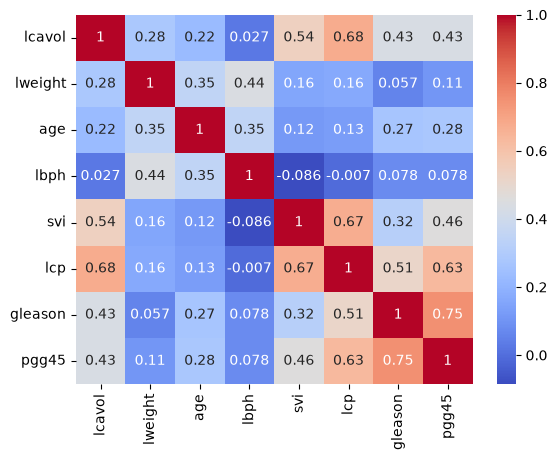

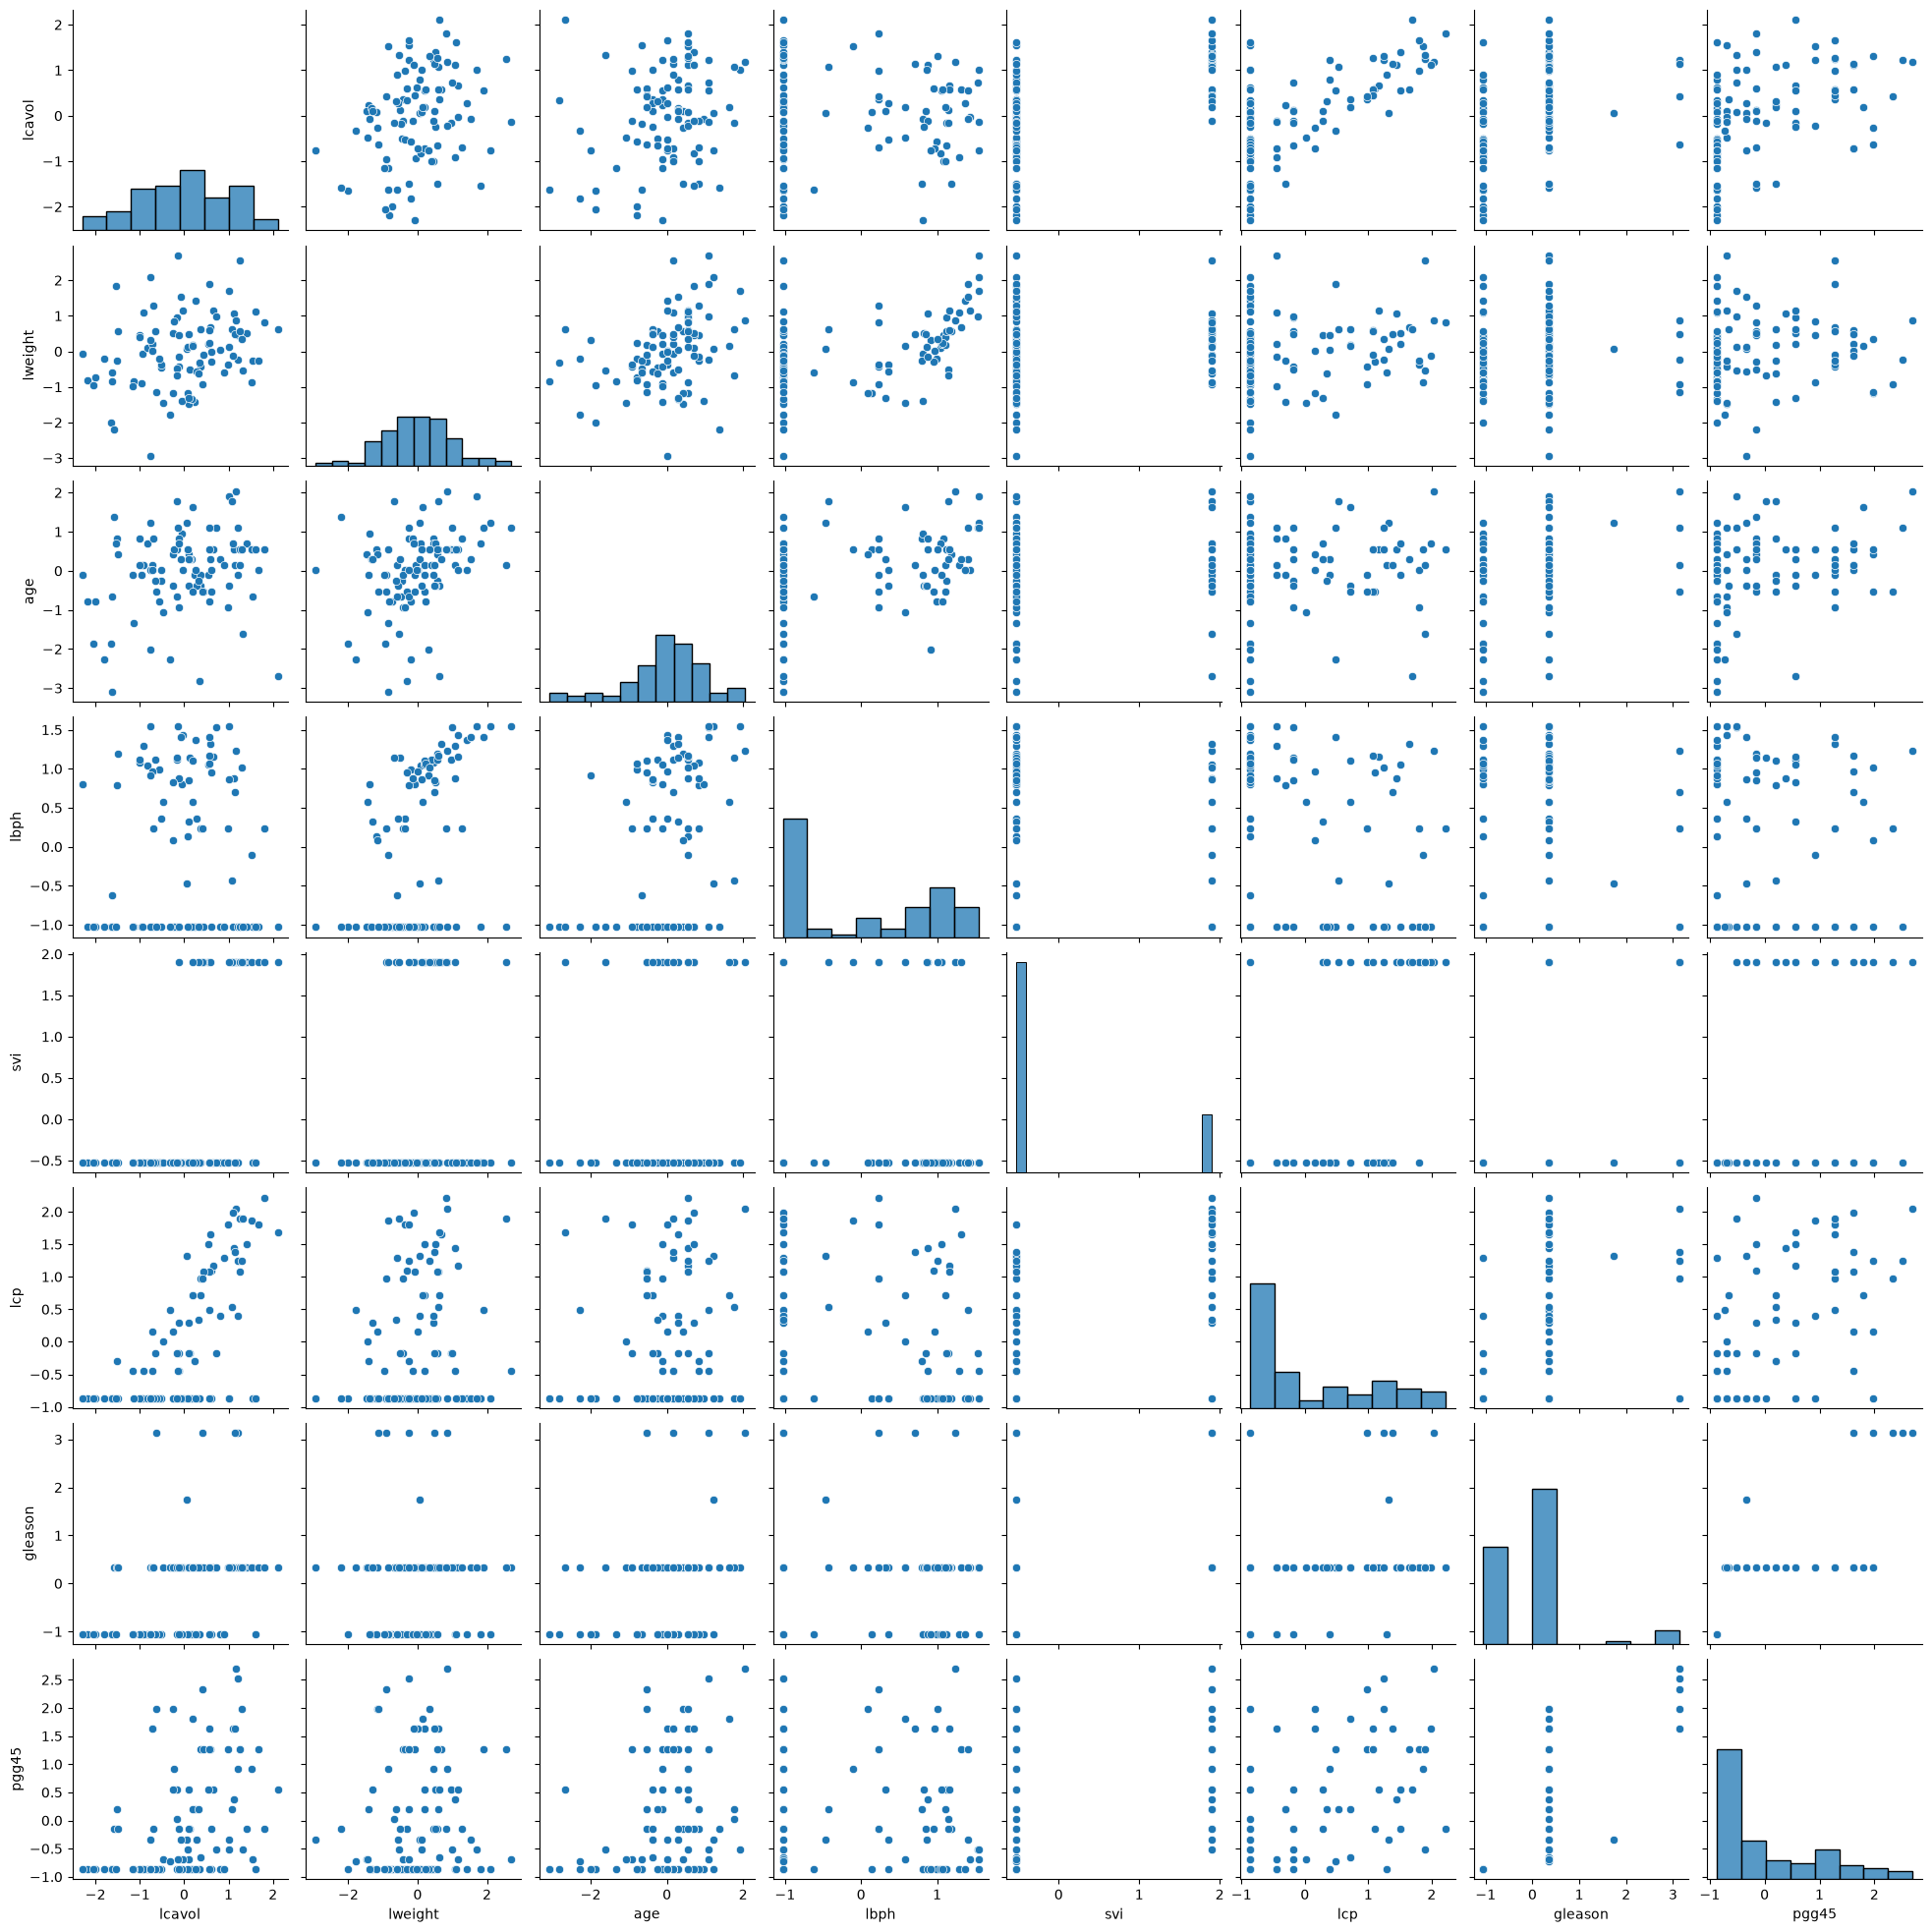

In [25]:
df = pd.read_csv('prostate.data.txt', sep=r'\s+', index_col=0)

# Display the dataframe
print(df.head())
print(df.describe())

# Examine the relation between the features using a correlation matrix and scatter plots
cols = ["lcavol", "lweight", "age", "lbph", "svi", "lcp", "gleason", "pgg45"]

# we standardize the features 
scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

correlations = df[cols].corr()
sns.heatmap(correlations, annot=True, cmap="coolwarm")

sns.pairplot(df[cols])

We fit a linear model to the log of prostate-specific antigen, lpsa, after
first standardizing the predictors to have unit variance. We randomly split
the dataset into a training set of size 67 and a test set of size 30. We ap-
plied least squares estimation to the training set, producing the estimates,
standard errors and Z-scores shown below

In [26]:
# split the data into training and testing sets based on the train column already provided in the dataset
train_data = df[df['train'] == 'T']
print(train_data.shape[0])
test_data  = df[df['train'] != 'T']   # or df[df['train'] == 'F'] if strictly 'F'
print(test_data.shape[0])


# Define features and target
X_train = train_data[cols]            # design matrix without the constant column
X_train_with_const = sm.add_constant(X_train) # Add a column of ones for the intercept

y_train = train_data['lpsa']          # target variable

# Fit the OLS model
model = sm.OLS(y_train, X_train_with_const).fit()

# 3. View summary (includes coefficients, p‑values, R², etc.)
print(model.summary())

67
30
                            OLS Regression Results                            
Dep. Variable:                   lpsa   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     16.47
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           2.04e-12
Time:                        20:41:30   Log-Likelihood:                -67.505
No. Observations:                  67   AIC:                             153.0
Df Residuals:                      58   BIC:                             172.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4649      0.089     27.598   

The predictor lcavol shows
the strongest eﬀect, with lweight and svi also strong.

We can also test for the exclusion of
a number of terms at once, using the F-statistic. 
Recall that

$$F = \frac{SSR_r-SSR_{ur}}{SSR_{ur}}\frac{df_{ur}}{df_{r}-df_{ur}}\sim_{H_0}\mathcal{F}\left(df_{r}-df_{ur}, df_{ur}\right)$$

For example, we
consider dropping all the non-significant terms in the above regression, namely age,
lcp, gleason, and pgg45.

In [27]:
cols_constrained = ["lcavol", "lweight", "lbph", "svi"]

X_constrained = train_data[cols_constrained]            # design matrix without the constant column
X_constrained = sm.add_constant(X_constrained) # Add a column of ones for the intercept

# Fit the OLS model
model_constrained = sm.OLS(y_train, X_constrained).fit()

# 3. View summary (includes coefficients, p‑values, R², etc.)
print(model_constrained.summary())


                            OLS Regression Results                            
Dep. Variable:                   lpsa   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     29.98
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           6.91e-14
Time:                        20:41:30   Log-Likelihood:                -71.156
No. Observations:                  67   AIC:                             152.3
Df Residuals:                      62   BIC:                             163.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4714      0.089     27.766      0.0

The test statistic is therefore equal to 

In [28]:
SSR_ur = model.ssr
SSR_r = model_constrained.ssr
df_ur = model.df_resid
df_r = model_constrained.df_resid

F = ((SSR_r - SSR_ur)/(SSR_ur))*(df_ur/(df_r - df_ur))
print(F)




1.6697548846375216


So that, 

$$F \approx 1.67\sim_{H_0}\mathcal{F}\left(4, 58\right)$$

Hence, the p-value is 


In [29]:
print(stats.f.sf(F, 4,58))  # p-value for the F-test

0.16933707265225179


Hence, we fail to reject $H_0$ and conclude that all of these excluded coefficients are jointly equal to zero.

We now compute the mean squared prediction error on the test data

$$MSPE = \frac{1}{n_{test}}\sum_{i=1}^{n_{test}}\left(\hat{y}_i-y_i\right)^2,$$

where $\hat{y}_i$ is the fitted value for observation $i$ in the full we just estimated on the train data, and $n_{test}$ is the number of observations in the test data. 




In [30]:

# Assuming you have:
# - model  : the fitted OLS model from statsmodels (with constant)
# - test_data : DataFrame containing test observations (already filtered)

# Prepare test features (add constant)
X_test = test_data[cols]
X_test_with_const = sm.add_constant(X_test)

# Predict on test set
y_pred = model.predict(X_test_with_const)

# Actual test target
y_test = test_data['lpsa']

# Compute MSPE (mean squared prediction error)
mspe = np.mean((y_pred - y_test)**2)
print(f"Mean Squared Prediction Error (MSPE) on test data: {mspe:.6f}")

Mean Squared Prediction Error (MSPE) on test data: 0.521274


In contrast, prediction using the mean training value of lpsa has a test error of

In [31]:
lpsa_training = train_data['lpsa']
mean_lpsa_training = lpsa_training.mean()
mspe_baseline = np.mean((mean_lpsa_training - y_test)**2)
print(f"Baseline MSPE (using mean of training lpsa): {mspe_baseline:.6f}")
print(mspe/mspe_baseline - 1)

Baseline MSPE (using mean of training lpsa): 1.056733
-0.5067118250228677


Hence, the linear model reduces the "base error rate" by about 50\%

# Ridge Regression

In [32]:
X_train = train_data[cols].values # design matrix on the training set (without the constant column)
y_train = train_data['lpsa'].values # outcome vector on the training set

X_test = test_data[cols].values # design matrix on the test set (without the constant column)
y_test = test_data['lpsa'].values # outcome vector on the test set

alphas = np.logspace(-3, 3, 100) # Grid of penalty strengths to search over

ridge_cv = RidgeCV(alphas=alphas, cv=10, scoring='neg_mean_squared_error') # CV10 ridge
ridge_cv.fit(X_train, y_train)

print("Best alpha:", ridge_cv.alpha_) # show the penalty value minimizing CV
print("Coefficients:") # print the associated coefficeints for each feature
for name, coef in zip(cols, ridge_cv.coef_):
    print(f"  {name}: {coef:.5f}")
print("Intercept:", ridge_cv.intercept_)

y_hat_ridge = ridge_cv.predict(X_test) # Predict on test set 

MSPE_ridge = np.mean((y_hat_ridge - y_test) ** 2) # MSPE
std_ridge  = np.sqrt(np.var((y_hat_ridge - y_test) ** 2) / len(y_test))

print("MSPE (ridge):", MSPE_ridge)
print("std (ridge):", std_ridge)

print(MSPE_ridge/mspe - 1)


Best alpha: 2.4770763559917115
Coefficients:
  lcavol: 0.62433
  lweight: 0.26121
  age: -0.12491
  lbph: 0.20303
  svi: 0.28938
  lcp: -0.21747
  gleason: -0.00153
  pgg45: 0.22694
Intercept: 2.4664951554974315
MSPE (ridge): 0.5036163078615299
std (ridge): 0.16657639303576044
-0.03387411890772307


Ridge reduces test error of LS estimates by a small amount. (around 5%)

7.446279645611002


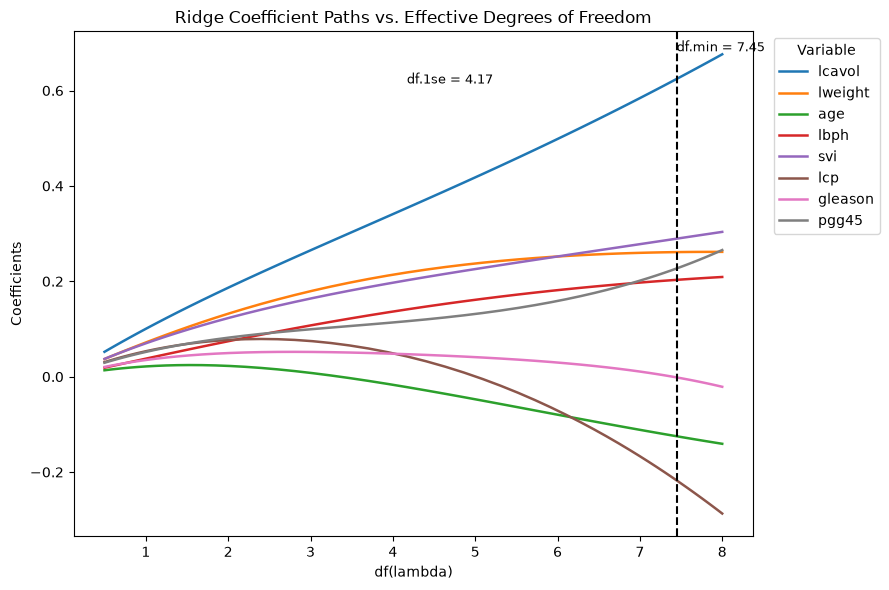

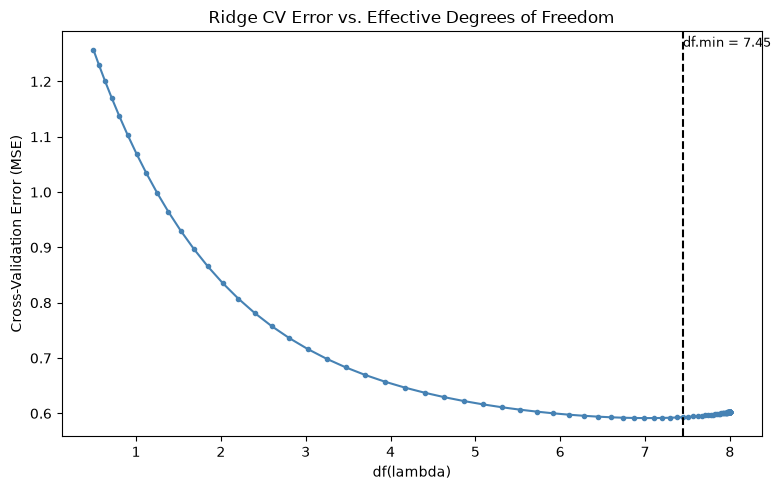

In [33]:
def df_lambda(lam, X):
    # Function to retrieve the effective degrees of freedom associated with lambda
    hat_lambda = X @ np.linalg.solve(
        X.T @ X + lam * np.eye(X.shape[1]),
        X.T
    )
    return np.trace(hat_lambda)

print(df_lambda(ridge_cv.alpha_, X_train_ridge)) # effective degrees of freedom associated with the best lambda

# --- Fit ridge at every alpha in the grid to get coefficient paths ---
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a, fit_intercept=True)
    ridge.fit(X_train_ridge, y_train_ridge)
    coefs.append(ridge.coef_)

coefs = np.array(coefs) 
dfs = np.array([df_lambda(a, X_train_ridge) for a in alphas]) # effective df at each alpha
df_min = df_lambda(ridge_cv.alpha_, X_train_ridge) # effective df at alpha.min

# --- Build long-format DataFrame for plotting ---
plot_data = pd.DataFrame(coefs, columns=cols)
plot_data['df'] = dfs

plot_data_long = plot_data.melt(id_vars='df', var_name='variable', value_name='coefficient')

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))
for var in cols:
    subset = plot_data_long[plot_data_long['variable'] == var]
    ax.plot(subset['df'], subset['coefficient'], label=var, linewidth=1.8)

ax.axvline(df_min, linestyle='--', color='black')

ax.text(df_min, plot_data_long['coefficient'].max(),
        f"df.min = {df_min:.2f}", ha='left', va='bottom', fontsize=9)
ax.text(df_1se, plot_data_long['coefficient'].max() * 0.9,
        f"df.1se = {df_1se:.2f}", ha='left', va='bottom', fontsize=9)

ax.set_xlabel("df(lambda)")
ax.set_ylabel("Coefficients")
ax.set_title("Ridge Coefficient Paths vs. Effective Degrees of Freedom")
ax.legend(title="Variable", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

kf = KFold(n_splits=10, shuffle=True, random_state=123)
grid = GridSearchCV(Ridge(), param_grid={'alpha': alphas}, cv=kf,
                     scoring='neg_mean_squared_error')
grid.fit(X_train_ridge, y_train_ridge)

cv_errors = -grid.cv_results_['mean_test_score']  # per-alpha mean CV MSE

# --- Plot CV error vs df ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dfs, cv_errors, marker='o', markersize=3, linewidth=1.5, color='steelblue')
ax.axvline(df_min, linestyle='--', color='black')
ax.text(df_min, max(cv_errors), f"df.min = {df_min:.2f}", ha='left', va='bottom', fontsize=9)

ax.set_xlabel("df(lambda)")
ax.set_ylabel("Cross-Validation Error (MSE)")
ax.set_title("Ridge CV Error vs. Effective Degrees of Freedom")
plt.tight_layout()
plt.show()

# LASSO

In [42]:
alphas = 10 ** np.linspace(10, -2, 100)

lasso_cv = LassoCV(cv=10, alphas=alphas) # CV10 LASSO
lasso_cv.fit(X_train, y_train)

print("Best alpha:", lasso_cv.alpha_) # show the penalty value minimizing CV
print("Coefficients:") # print the associated coefficeints for each feature
for name, coef in zip(cols, lasso_cv.coef_):
    print(f"  {name}: {coef:.5f}")
print("Intercept:", lasso_cv.intercept_)

y_hat_lasso = lasso_cv.predict(X_test) # Predict on test set

MSPE_lasso = np.mean((y_hat_lasso - y_test) ** 2) # MSPE
std_lasso  = np.sqrt(np.var((y_hat_lasso - y_test) ** 2) / len(y_test))

print("MSPE (lasso):", MSPE_lasso)
print("std (lasso):", std_lasso)

print(MSPE_lasso/MSPE_ridge - 1)
print(MSPE_lasso/mspe - 1)

Best alpha: 0.01
Coefficients:
  lcavol: 0.64739
  lweight: 0.25763
  age: -0.12000
  lbph: 0.19759
  svi: 0.28289
  lcp: -0.22387
  gleason: -0.00000
  pgg45: 0.21899
Intercept: 2.467033419306766
MSPE (lasso): 0.49894158365908614
std (lasso): 0.16468636906164405
-0.009282313001923392
-0.04284200173528063
